
# Домашнее задание: Метрики и функции потерь в регрессии  
**Датасет:** scikit-learn/auto-mpg  
**Целевая переменная:** mpg


In [26]:
# Импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

## 1. Загрузка данных

In [27]:
df = load_dataset("scikit-learn/auto-mpg")["train"].to_pandas()
df = df.dropna().reset_index(drop=True)
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


## 2. Разбиение данных (60/20/20)

In [28]:
X = df.drop(columns=["mpg"])
y = df["mpg"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE  # 0.25 * 0.8 = 0.2
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (238, 8)
Val: (80, 8)
Test: (80, 8)


## 3. Препроцессинг (без утечек через Pipeline)

In [29]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

## 4. Бейзлайн-модели

In [30]:
mean_pred = np.full_like(y_val, y_train.mean(), dtype=np.float64)
median_pred = np.full_like(y_val, y_train.median(), dtype=np.float64)

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

baseline_results = pd.DataFrame(
    [
        evaluate(y_val, mean_pred),
        evaluate(y_val, median_pred),
    ],
    columns=["MAE", "RMSE", "R2"],
    index=["Mean baseline", "Median baseline"]
)

baseline_results

,MAE,RMSE,R2
Mean baseline,7.234727,8.728830,-0.025648
Median baseline,7.288750,8.971817,-0.083545


## 4.1. Анализ бейзлайнов

Константные модели дают отрицательный R², что ожидаемо — они не используют признаки.
Медиана обычно показывает меньший MAE, так как менее чувствительна к выбросам.
Это задаёт нижнюю границу качества моделей.

## 5. LinearRegression (MSE)

In [31]:
linreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linreg_pipeline.fit(X_train, y_train)
y_val_pred = linreg_pipeline.predict(X_val)

linreg_results = evaluate(y_val, y_val_pred)
linreg_results

(5.612798495002709, np.float64(7.295296535767984), 0.28357280157435194)

### 5.1. Визуализация

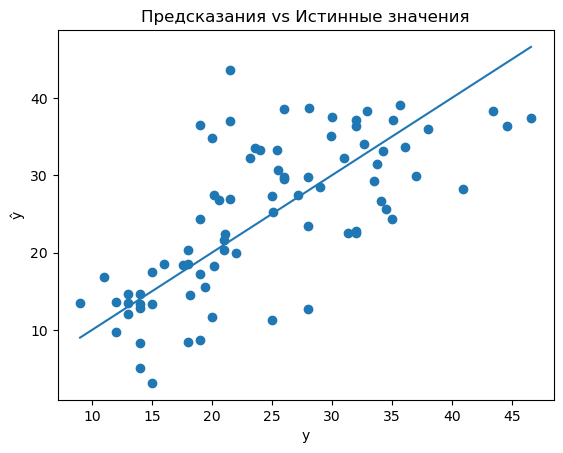

In [32]:
# Scatter
plt.figure()
plt.scatter(y_val, y_val_pred)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()])
plt.xlabel("y")
plt.ylabel("ŷ")
plt.title("Предсказания vs Истинные значения")
plt.show()

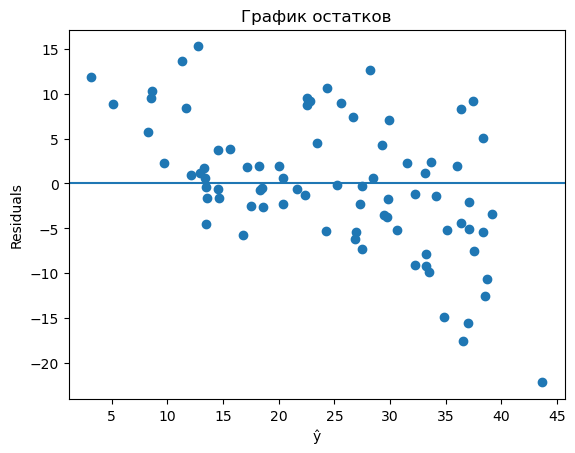

In [33]:
# Residuals
residuals = y_val - y_val_pred

plt.figure()
plt.scatter(y_val_pred, residuals)
plt.axhline(0)
plt.xlabel("ŷ")
plt.ylabel("Residuals")
plt.title("График остатков")
plt.show()

## 5.2. Анализ остатков

Ошибки распределены вокруг нуля, что говорит об отсутствии сильного смещения.
Однако заметны выбросы и увеличение разброса ошибок при больших ŷ — признаки гетероскедастичности.
Это указывает на возможную нелинейность зависимости.

## 6. Сравнение функций потерь (SGDRegressor)

In [34]:
sgd_mse = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        loss="squared_error",
        max_iter=5000,
        tol=1e-4,
        learning_rate="adaptive",
        eta0=0.01,
        random_state=RANDOM_STATE
    ))
])

sgd_mae = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SGDRegressor(
        loss="epsilon_insensitive",
        epsilon=0.1,
        max_iter=5000,
        tol=1e-4,
        learning_rate="adaptive",
        eta0=0.01,
        random_state=RANDOM_STATE
    ))
])

sgd_mse.fit(X_train, y_train)
sgd_mae.fit(X_train, y_train)

sgd_mse_results = evaluate(y_val, sgd_mse.predict(X_val))
sgd_mae_results = evaluate(y_val, sgd_mae.predict(X_val))

#sgd_mse_results, sgd_mae_results

print("SGD (MSE):")
print(f"MAE: {sgd_mse_results[0]:.2f}")
print(f"RMSE: {sgd_mse_results[1]:.2f}")
print(f"R2: {sgd_mse_results[2]:.2f}\n")

print("SGD (MAE):")
print(f"MAE: {sgd_mae_results[0]:.2f}")
print(f"RMSE: {sgd_mae_results[1]:.2f}")
print(f"R2: {sgd_mae_results[2]:.2f}")

SGD (MSE):
MAE: 5.71
RMSE: 7.54
R2: 0.24

SGD (MAE):
MAE: 5.61
RMSE: 7.34
R2: 0.27


## 6.1. Анализ

MSE сильнее штрафует большие ошибки, поэтому обычно показывает лучший RMSE.
MAE более устойчива к выбросам, но может давать чуть большую среднюю ошибку.
Различия подтверждают влияние функции потерь на распределение ошибок.

## 7. Сводная таблица метрик

In [35]:
results = pd.DataFrame({
    "Model": ["Mean baseline", "Median baseline", "LinearRegression", "SGD (MSE)", "SGD (MAE)"],
    "MAE": [baseline_mean[0], baseline_median[0], linreg_results[0], sgd_mse_results[0], sgd_mae_results[0]],
    "RMSE": [baseline_mean[1], baseline_median[1], linreg_results[1], sgd_mse_results[1], sgd_mae_results[1]],
    "R2": [baseline_mean[2], baseline_median[2], linreg_results[2], sgd_mse_results[2], sgd_mae_results[2]]
})

results

,Model,MAE,RMSE,R2
0,Mean baseline,7.234727,8.728830,-0.025648
1,Median baseline,7.288750,8.971817,-0.083545
2,LinearRegression,5.612798,7.295297,0.283573
3,SGD (MSE),5.714243,7.537552,0.235202
4,SGD (MAE),5.607011,7.344819,0.273813


## 8. Q–Q график остатков

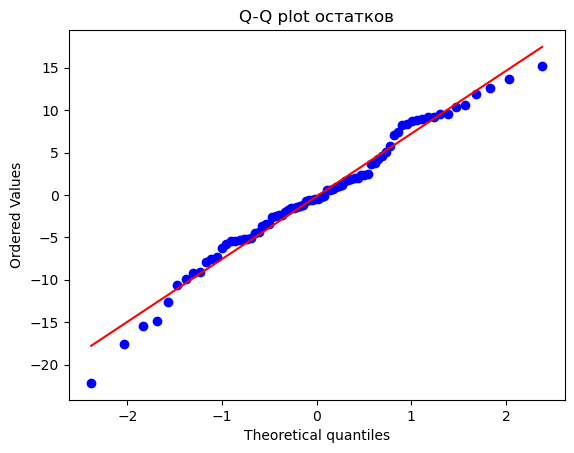

In [36]:
plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot остатков")
plt.show()

## 9. Финальная оценка на тестовой выборке

In [37]:
best_model = linreg_pipeline  # при необходимости можно заменить

y_test_pred = best_model.predict(X_test)
test_results = evaluate(y_test, y_test_pred)

pd.DataFrame([test_results], columns=["MAE", "RMSE", "R2"], index=["Test results"])

,MAE,RMSE,R2
Test results,6.090593,7.450389,-0.032397


## 10. Выводы

- Линейная модель значительно превосходит константные бейзлайны.
- MSE чувствительна к выбросам, MAE более устойчива.
- Метрики на тестовой выборке сопоставимы с валидационной — модель стабильна.